# Imports

In [6]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.nn.parameter import Parameter

# Functions

## Premises

### gaussian2

In [28]:
def gaussian2(x, p):
    '''
    Calculates Gaussian values based on the input data and premise parameters of the ANFIS model 
    (is used as a membership function). It also works with more than one input (batches).

    Parameters:
    - x (torch.Tensor): Input data tensor (as a batch or a single input).
    - p (torch.Tensor): 3D tensor containing 'mu' and 'sigma' parameters by data dimension
                        and by ANFIS rule.

    Returns:
    - torch.Tensor: Tensor with resulting Gaussian values (either as a batch or a single output).

    Explanation:
    This function calculates Gaussian values based on the input data `x` and the parameters `p`.
    It ensures that the standard deviation values in `p` are not zero by replacing them with a small
    value (1e-6). The formula used to compute the Gaussian values is:

    \[ \exp\left(-0.5 \cdot \left(\frac{x - p[:, :, 0]}{p[:, :, 1]}\right)^2\right) \]

    Note:
    - If `p[:, :, 1]` is zero, it is replaced with 1e-6 to prevent division by zero.

    '''
    return torch.exp(-0.5 * torch.pow((x - p[:, :, 0])/torch.where(p[:, :, 1] == 0, torch.tensor(1e-6), p[:, :, 1]), 2))

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_3837/4237469877.py:2: SyntaxWarning: invalid escape sequence '\['
  '''


### generalized_bell

In [29]:
def generalized_bell(x, p):
    '''
    Calculates Generalized Bell values based on the input data and premise parameters of the ANFIS model.

    Parameters:
    - x (torch.Tensor): Input data tensor (as a batch or a single input).
    - p (torch.Tensor): 3D tensor containing 'A', 'B' and 'C' parameters by data dimension
                        and by ANFIS rule. The parameters represents the shape of the Bell curve,
                        meaning the width, slope and height respectively.

    Returns:
    - torch.Tensor: 2D or 3D tensor with Resulting Generalized Bell values (for single or batch input
                    respectively).

    Explanation:
    This function calculates Generalized Bell values based on the input data `x` and the parameters `p`.
    It ensures that the standard deviation values in `p` are not zero by replacing them with a small
    value (1e-6). The formula used to compute the Generalized Bell values is:

    \[ \frac{1}{1 + \exp\left(-0.5 \cdot \left(\frac{|x - p[:, :, 2}|}{p[:, :, 0]}\right)^2\right)} \]

    Note:
    - If `p[:, :, 0]` is zero, it is replaced with 1e-6 to prevent division by zero.

    '''
    return 1/(1 + torch.pow(torch.abs((x - p[:, :, 2])/torch.where(p[:, :, 0] == 0, torch.tensor(1e-6), p[:, :, 0])), 2*p[:, :, 1]))

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_3837/4188964859.py:2: SyntaxWarning: invalid escape sequence '\['
  '''


## Consequents

### Weighted Linear

In [30]:
def weighted_linear(x, c, w):
    """
    Compute the weighted linear combination of input features and coefficients (representing the
    consequent parameters of the ANFIS model). It is manufactured in such a way that it also works with
    more than one input (batches) and will be used to calculate the individual outputs of each rule of
    the ANFIS model.

    Parameters:
    - x (torch.Tensor): Input data tensor.
    - c (torch.Tensor): Coefficients tensor for the linear combination (consequent parameters).
    - w (torch.Tensor): Weights tensor for element-wise multiplication.

    Returns:
    - torch.Tensor: Resulting weighted linear combination.

    Explanation:
    This function calculates the weighted linear combination of the input features `x` and the coefficients `c`.
    It involves matrix multiplication of the input features by the transposed coefficients (excluding the last column),
    adding the last column of coefficients, and then element-wise multiplication by the weights `w`.
    The formula used is:

    \[ (x \cdot c[:, :-1].T + c[:, -1]) \cdot w \]

    Note:
    - The weights `w` are applied element-wise.

    """
    return (torch.bmm(x.unsqueeze(0).expand(c[:, :, :-1].size(0), -1, -1), torch.transpose(c[:, :, :-1], 1, 2)) + c[:, :, -1].unsqueeze(1)).mul(w.unsqueeze(0))

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_3837/724767595.py:2: SyntaxWarning: invalid escape sequence '\['
  """


# Restricted ANFIS with multiple outputs

## Structures (for layers)

### Layer 1: Fuzzify

#### Implementation

In [31]:
class FuzzifyLayer(nn.Module):
    '''
    Fuzzification layer of an Adaptive Neuro-Fuzzy Inference System (ANFIS) model.

    Attributes:
    - input_size (int): The size of the input features.
    - dtype (torch.dtype): The data type of the input data (to initialize the premises)
    - mf (function): Membership function to use (default: generalized_bell).
    - params (list): List of parameter names for the membership function (default: ['a', 'b', 'c']).
    - premises (torch.nn.Parameter): Trainable parameters for the fuzzification layer.

    Methods:
    - __init__: Initializes a new FuzzifyLayer instance.
    - init_premises: Initializes the premises based on input training data.
    - forward: Performs a forward pass through the fuzzification layer.
    - premises_structure: Prints the structure of the fuzzy premises as a Pandas dataframe.
    - plot_premises: Plots the fuzzy rules.

    Example Usage:
    >>> input_data = torch.randn((3, 4))
    >>> fuzzify_layer = FuzzifyLayer(input_data, init_rules=3)
    >>> membership_values = fuzzify_layer(input_data)
    '''
    
    
    def __init__(self, x_train, init_rules=1, mf=generalized_bell, params=['a', 'b', 'c'], init_mode=0):
        """
        Initializes a new FuzzifyLayer instance.

        Parameters:
        - x_train (torch.tensor): Input training data.
        - init_rules (int): The number of initial fuzzy rules (default: 1).
        - mf (function): Membership function to use (default: generalized_bell).
        - params (list): List of parameter names for the membership function (default: ['a', 'b', 'c']).
        - init_mode (int): Numeric flag for initializing the fuzzy premises (default: 0, meaning it will be initialized based on the input data,
                           otherwise it will be initialized randomly).

        """
        super(FuzzifyLayer, self).__init__()
        # Input data info
        self.input_size = x_train.shape[1]
        self.dtype = x_train.dtype
        self.max_val = torch.max(x_train).round().item()
        self.min_val = torch.min(x_train).round().item()
        
        self.input_shape = x_train.shape # QUIZAS SEA MAS CONVENIENTE OBTENER INFO DIRECTAMENTE DESDE SHAPE
        
        # Fuzzification parameters
        self.mf = mf
        self.params = params

        # Initialize premises
        self.premises = Parameter(self.init_premises(x_train, init_rules, init_mode), requires_grad=True)



    def init_premises(self, x_train, init_rules, init_mode):
        """
        Initializes the fuzzy premises based on input training data.

        Parameters:
        - x_train (torch.Tensor): Training data for initializing fuzzy premises.
        - init_rules (int): The number of initial fuzzy rules.

        Returns:
        - torch.Tensor: Initialized fuzzy premises.

        """
        premises = torch.zeros(self.input_size, init_rules, len(self.params), dtype=self.dtype)
        
        if init_mode != 0:
            premises += 2 * torch.rand(self.input_size, init_rules, len(self.params), dtype=self.dtype) - 1

        elif self.mf == gaussian2:
            if init_rules > 1:
                min = torch.min(x_train, dim=0).values
                max = torch.max(x_train, dim=0).values
                stp = (max - min) / (init_rules - 1)
                for i in range(self.input_size):
                    h = torch.arange(min[i], max[i] + stp[i], stp[i])
                    premises[i, :, 0] = h[:init_rules]
                    premises[i, :, 1] = stp[i]/2
            else:
                for i in range(self.input_size):
                    premises[i, :, 0] = torch.mean(x_train[:, i])
                    premises[i, :, 1] = torch.std(x_train[:, i])

        elif self.mf == generalized_bell:
            if init_rules > 1:
                min = torch.min(x_train, dim=0).values
                max = torch.max(x_train, dim=0).values
                stp = (max - min) / (init_rules - 1)
                for i in range(self.input_size):
                    h = torch.arange(min[i], max[i] + stp[i], stp[i])
                    premises[i, :, 2] = h[:init_rules] # C : centro
                    premises[i, :, 0] = stp[i]/2 # A : ancho
                    premises[i, :, 1] = 8 # B : pendiente
            else:
                for i in range(self.input_size):
                    premises[i, :, 2] = torch.mean(x_train[:, i]) # C : centro
                    premises[i, :, 0] = torch.std(x_train[:, i]) # A : ancho
                    premises[i, :, 1] = 2 # B : pendiente

        return premises



    def forward(self, x):
        """
        Performs a forward pass through the fuzzification layer.

        Parameters:
        - x (torch.Tensor): Input tensor.

        Returns:
        - torch.Tensor: Output tensor (membership values).

        """
        return self.mf(x.unsqueeze(x.dim()), self.premises)


    @property
    def premises_structure(self):
        """
        return the structure of the fuzzy premises on a dataframe.

        """
        df = pd.DataFrame()
        rules = ['Fuzzy rule {}'.format(i) for i in range(1, self.premises.data.shape[1]+1)]

        for i in range(self.input_size):
            for j in range(len(self.params)):
                column = pd.Series(self.premises.data[i,:,j], index=rules, name=self.params[j] + f' (x{i})', )
                df[self.params[j] + f' (x{i})'] = column

        return df


    
    @property
    def plot_premises(self):
        """
        plot the fuzzy rules.

        """
        variables = [f'x{i}' for i in range(self.input_size)]
        dataframe = self.premises_structure
        
        sep = round((0.1*(self.max_val - self.min_val))) + 1
        x = np.linspace(self.min_val - sep, self.max_val + sep, 500) 

        fig, axes = plt.subplots(nrows=self.premises.data.shape[1], ncols=len(variables), figsize=(15, 8), sharex=True, sharey=True)

        for i, rule in enumerate(dataframe.index):
            for j, var in enumerate(variables):

                if self.mf == gaussian2:
                    mu = dataframe.loc[rule, f'mu ({var})']
                    sigma = dataframe.loc[rule, f'sigma ({var})']
                    y = np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

                elif self.mf == generalized_bell:
                    a = dataframe.loc[rule, f'a ({var})']
                    b = dataframe.loc[rule, f'b ({var})']
                    c = dataframe.loc[rule, f'c ({var})']
                    y = 1/(1 + np.power(np.abs((x - c) / a), 2*b))

                ax = axes[i, j]
                ax.plot(x, y, label=f'{rule}, {var}')
                ax.set_title(f'{rule}, {var}')
                ax.grid(True)
                if i == self.premises.data.shape[1] - 1:
                    ax.set_xlabel('x')
                if j == 0:
                    ax.set_ylabel('Membership Value')

        plt.tight_layout()
        plt.show()

        return None

#### Compute

In [32]:
x_train = torch.randn((5, 3))
x_train

tensor([[ 1.6494, -0.9779,  1.5458],
        [-0.9016,  1.3566, -0.2904],
        [-2.2150, -1.8111,  0.5437],
        [ 2.4748,  1.6118, -1.1930],
        [-0.1553,  0.4359,  1.2189]])

In [33]:
single_x = x_train[0]
single_x

tensor([ 1.6494, -0.9779,  1.5458])

In [34]:
fuzzy_layer = FuzzifyLayer(x_train, init_rules=5)
fuzzy_layer.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1),a (x2),b (x2),c (x2)
Fuzzy rule 1,0.586215,8.0,-2.214968,0.427857,8.0,-1.811066,0.342348,8.0,-1.192992
Fuzzy rule 2,0.586215,8.0,-1.042539,0.427857,8.0,-0.955351,0.342348,8.0,-0.508296
Fuzzy rule 3,0.586215,8.0,0.129891,0.427857,8.0,-0.099636,0.342348,8.0,0.176400
Fuzzy rule 4,0.586215,8.0,1.302321,0.427857,8.0,0.756079,0.342348,8.0,0.861097
Fuzzy rule 5,0.586215,8.0,2.474751,0.427857,8.0,1.611794,0.342348,8.0,1.545793


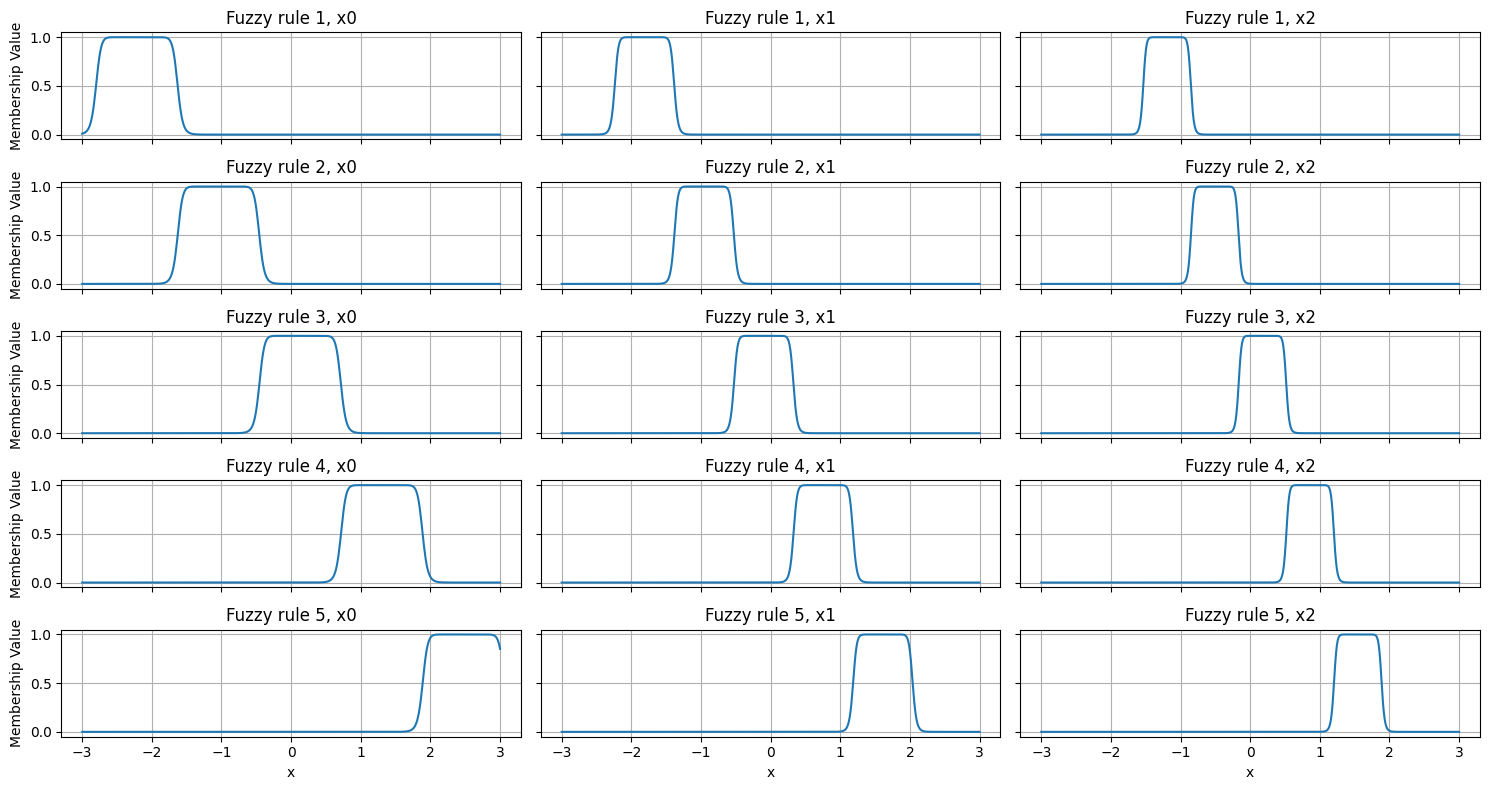

In [35]:
fuzzy_layer.plot_premises

In [36]:
fuzzy_output = fuzzy_layer(x_train)
'''
batch input 1
[[[mf(rule1), mf(rule2)],   (x0)
  [mf(rule1), mf(rule2)]    (x1)
  [mf(rule1), mf(rule2)]],  (x2)

batch input 2
[[[mf(rule1), mf(rule2)],   (x0)
  [mf(rule1), mf(rule2)]    (x1)
  [mf(rule1), mf(rule2)]],  (x2)

  ...

last batch input
[[[mf(rule1), mf(rule2)],   (x0)
  [mf(rule1), mf(rule2)]    (x1)
  [mf(rule1), mf(rule2)]],  (x2)
'''
fuzzy_output

tensor([[[7.8635e-14, 2.5575e-11, 2.4075e-07, 9.9977e-01, 4.1788e-03],
         [2.3403e-05, 1.0000e+00, 1.0060e-05, 1.8879e-10, 3.0814e-13],
         [3.5527e-15, 3.5447e-13, 2.3283e-10, 1.5259e-05, 1.0000e+00]],

        [[2.4830e-06, 1.0000e+00, 1.1833e-04, 6.2751e-10, 6.8179e-13],
         [1.2273e-14, 1.8929e-12, 3.0838e-09, 4.3898e-03, 9.9974e-01],
         [1.8357e-07, 9.9928e-01, 6.9507e-03, 3.7252e-09, 2.1316e-12]],

        [[1.0000e+00, 1.5259e-05, 2.3283e-10, 3.5447e-13, 3.5527e-15],
         [1.0000e+00, 1.5259e-05, 2.3283e-10, 3.5447e-13, 3.5527e-15],
         [5.1986e-12, 1.5820e-08, 2.4490e-01, 7.7052e-01, 3.4437e-08]],

        [[3.5527e-15, 3.5447e-13, 2.3283e-10, 1.5258e-05, 1.0000e+00],
         [3.5527e-15, 3.5447e-13, 2.3283e-10, 1.5259e-05, 1.0000e+00],
         [1.0000e+00, 1.5259e-05, 2.3283e-10, 3.5447e-13, 3.5527e-15]],

        [[1.8545e-09, 1.3178e-03, 9.9999e-01, 4.6828e-07, 3.7105e-11],
         [2.9862e-12, 6.3989e-09, 2.6784e-02, 9.9044e-01, 9.4433e-08]

In [37]:
single_fuzzy_output = fuzzy_layer(single_x)
single_fuzzy_output

tensor([[7.8635e-14, 2.5575e-11, 2.4075e-07, 9.9977e-01, 4.1788e-03],
        [2.3403e-05, 1.0000e+00, 1.0060e-05, 1.8879e-10, 3.0814e-13],
        [3.5527e-15, 3.5447e-13, 2.3283e-10, 1.5259e-05, 1.0000e+00]],
       grad_fn=<MulBackward0>)

### Layer 2: Firing Levels

#### Implementation

In [38]:
class FiringLevelsLayer(nn.Module):
    """
    Class for calculating firing levels in an Adaptive Neuro-Fuzzy Inference System (ANFIS) model.

    Methods:
    - __init__: Initializes a new FiringLevelsLayer instance.
    - forward: Performs a forward pass to calculate firing levels.

    Example Usage:
    >>> firing_levels_layer = FiringLevelsLayer()
    >>> firing_levels = firing_levels_layer(membership_values) #assuming 'membership_values' is the tensor obtained from the Fuzzification Layer

    """
    def __init__(self):
        """
        Initializes a new FiringLevelsLayer instance.

        """
        super(FiringLevelsLayer, self).__init__()


    def forward(self, m):
        """
        Performs a forward pass through the layer to calculate firing levels.

        Parameters:
        - m (torch.Tensor): Input tensor containing the membership values for each rule.

        Returns:
        - torch.Tensor: Output tensor (Firing levels).

        """
        w = m.prod(dim=m.dim()-2)
        return w

#### Compute

In [39]:
firing_levels_layer = FiringLevelsLayer()

In [40]:
firing_levels_output = firing_levels_layer(fuzzy_output)
'''
[[w(rule1), w(rule2)],  (of batch input1)
 [w(rule1), w(rule2)],  (of batch input2)
 ...
 [w(rule1), w(rule2)]]  (of last batch input)
'''
firing_levels_output

tensor([[6.5381e-33, 9.0655e-24, 5.6388e-22, 2.8801e-15, 1.2877e-15],
        [5.5941e-27, 1.8916e-12, 2.5363e-15, 1.0262e-20, 1.4529e-24],
        [5.1986e-12, 3.6833e-18, 1.3276e-20, 9.6815e-26, 4.3465e-37],
        [1.2622e-29, 1.9172e-30, 1.2622e-29, 8.2529e-23, 3.5527e-15],
        [1.5031e-34, 4.7843e-23, 4.8966e-10, 1.5306e-07, 2.3729e-18]],
       grad_fn=<ProdBackward1>)

In [41]:
single_firing_levels_output = firing_levels_layer(single_fuzzy_output)
single_firing_levels_output

tensor([6.5381e-33, 9.0655e-24, 5.6388e-22, 2.8801e-15, 1.2877e-15],
       grad_fn=<ProdBackward1>)

### Layer 3: Normalization

#### Implementation

In [42]:
class NormalizationLayer(nn.Module):
    """
    Class for normalize the firing levels in an Adaptive Neuro-Fuzzy Inference System (ANFIS) model.

    Methods:
    - __init__: Initializes a new NormalizeLayer instance.
    - forward: Performs a forward pass to normalize the firing levels obtained on a previous layer.

    Example Usage:
    >>> normalization_layer = NormalizationLayer()
    >>> norm_firing_levels = normalization_layer(firing_levels) #assuming 'firing_levels' is the tensor obtained from the Firing Levels Layer

    """
    def __init__(self):
        """
        Initializes a new FiringLevelsLayer instance.

        """
        super(NormalizationLayer, self).__init__()


    def forward(self, w):
        """
        Performs a forward pass through the layer to normalize the firing levels.

        Parameters:
        - x (torch.Tensor): Input tensor containing the membership values for each rule.

        Returns:
        - torch.Tensor: Output tensor (Normalized Firing levels).

        """
        sum = torch.sum(w, dim=-1, keepdim=True)
        sum[sum == 0] = 1
        w = w/sum
        return w

#### Compute

In [43]:
normalization_layer = NormalizationLayer()

In [44]:
normalization_output = normalization_layer(firing_levels_output)
'''
[[~w(rule1), ~w(rule2)],  (of batch input1)
 [~w(rule1), ~w(rule2)],  (of batch input2)
 ...
 [~w(rule1), ~w(rule2)]]  (of last batch input)
'''
normalization_output

tensor([[1.5687e-18, 2.1752e-09, 1.3530e-07, 6.9104e-01, 3.0896e-01],
        [2.9535e-15, 9.9866e-01, 1.3391e-03, 5.4177e-09, 7.6709e-13],
        [1.0000e+00, 7.0851e-07, 2.5538e-09, 1.8623e-14, 8.3609e-26],
        [3.5527e-15, 5.3965e-16, 3.5527e-15, 2.3230e-08, 1.0000e+00],
        [9.7894e-28, 3.1159e-16, 3.1890e-03, 9.9681e-01, 1.5454e-11]],
       grad_fn=<DivBackward0>)

In [45]:
single_normalization_output = normalization_layer(single_firing_levels_output)
single_normalization_output

tensor([1.5687e-18, 2.1752e-09, 1.3530e-07, 6.9104e-01, 3.0896e-01],
       grad_fn=<DivBackward0>)

### Layer 4: Consequent

#### Implementation

In [46]:
class ConsequentLayer(nn.Module):
    """
    Class for representing the fourth layer (consequent layer) of an Adaptive Neuro-Fuzzy Inference System (ANFIS) model.

    Attributes:
    - function (function): Consequent function to use (default: weighted_linear).
    - consequents (torch.nn.Parameter): Trainable parameters for the consequent layer.


    Methods:
    - __init__: Initializes a new ConsequentLayer instance.
    - forward: Performs a forward pass to calculate the consequent layer output.
    - consequents_structure: Prints the structure of the consequent parameters.

    Example Usage:
    >>> input_data = torch.randn((5, 3))  # Assuming input tensor shape (batch_size, num_input_features)
    >>> consequent_layer = ConsequentLayer(input_data.shape[1], input_data.dtype, init_rules=2)
    >>> output = consequent_layer(input_data, weights) # Assuming weight is the tensor obtained from the normalization layer with shape (batch_size, num_rules)

    """
    def __init__(self, input_size, dtype, init_rules=1, function=weighted_linear, outputs=1):
        """
        Initializes a new ConsequentLayer instance.

        Parameters:
        - input_size (int): Number of input features.
        - dtype (torch.dtype): Data type for the consequents.
        - init_rules (int): Number of initial rules.
        - function (callable): Consequent function to apply.
        - outputs (int): Number of outputs.

        """
        super(ConsequentLayer, self).__init__()
        self.function = function
        self.consequents = Parameter(2 * torch.rand(outputs, init_rules, input_size + 1, dtype=dtype) - 1, requires_grad=True)


    def forward(self, x, w):
        """
        Performs a forward pass to calculate the consequent layer output.

        Parameters:
        - x (torch.Tensor): Input tensor.
        - w (torch.Tensor): Weights tensor.

        Returns:
        - torch.Tensor: Output tensor (Outputs by rule of the ANFIS model).

        """
        outputs = self.function(x, self.consequents, w)
        return outputs


    @property
    def consequents_structure(self):
        """
        Returns the structure of the consequent parameters on a list of Pandas dataframes.
        Each element of the list represents the consequents of one of the outputs.

        """
        dfs = [pd.DataFrame() for _ in range(self.consequents.data.shape[0])]

        rules = ['rule {}'.format(i) for i in range(1, self.consequents.data.shape[1]+1)]

        for o in range(self.consequents.data.shape[0]):
            for i in range(self.consequents.data.shape[2]):
                name=f'c{i} (x{i})'
                if (i == self.consequents.data.shape[2]-1): name=f'c{i}'
                column = pd.Series(self.consequents.data[o,:,i], index=rules, name=name)
                dfs[o][name] = column

        return dfs

#### Compute

In [47]:
consequent_layer = ConsequentLayer(x_train.shape[1], fuzzy_layer.dtype, init_rules=5)

In [48]:
dfs = consequent_layer.consequents_structure
dfs

[         c0 (x0)   c1 (x1)   c2 (x2)        c3
 rule 1 -0.090208 -0.235022  0.112897 -0.095346
 rule 2  0.146612  0.604579 -0.352792  0.965042
 rule 3  0.056652  0.061703  0.089822 -0.920210
 rule 4 -0.155204 -0.234429 -0.289692 -0.245025
 rule 5  0.038089  0.163533 -0.925527 -0.558250]

In [50]:
consequent_output = consequent_layer(x_train, normalization_output)
'''fi = x1*c1i + x2*c2i + c3i, con c1i, c2i, c3i consequent parameters of rule i

[[f1, f2],  (of batch input1)
 [f1, f2],  (of batch input2)
 ...
 [f1, f2]] (of last batch input)
 ]
'''
consequent_output

tensor([[[ 2.5133e-19,  1.5290e-10, -1.0124e-07, -4.9725e-01, -6.4450e-01],
         [-1.0799e-15,  1.7531e+00, -1.2235e-03, -1.8365e-09, -7.8205e-14],
         [ 5.9149e-01, -4.5801e-07, -2.8312e-09,  6.8125e-15, -1.2056e-25],
         [-2.9561e-15,  1.4696e-15, -2.7985e-15, -1.5363e-08,  9.0374e-01],
         [-4.5204e-29,  2.4173e-16, -2.5277e-03, -6.7407e-01, -2.5052e-11]]],
       grad_fn=<MulBackward0>)

In [51]:
single_consequent_output = consequent_layer(single_x, single_normalization_output)
single_consequent_output

tensor([[[ 2.5133e-19,  1.5290e-10, -1.0124e-07, -4.9725e-01, -6.4450e-01]]],
       grad_fn=<MulBackward0>)

#### Testing for uANFIS

In [52]:
x_train2 = torch.randn((5,2))
x_train2

tensor([[ 0.0453, -0.8129],
        [-0.6131,  0.4324],
        [-0.2606,  0.0204],
        [ 0.1973,  1.6162],
        [ 0.3923, -0.5639]])

In [56]:
fuzzy_layer2 = FuzzifyLayer(x_train2, init_rules=3)
fuzzy_output2 = fuzzy_layer2(x_train2)
firing_levels_layer2 = FiringLevelsLayer()
firing_levels_output2 = firing_levels_layer2(fuzzy_output2)
normalization_layer2 = NormalizationLayer()
normalization_output2 = normalization_layer2(firing_levels_output2)
normalization_output2


tensor([[1.3177e-02, 9.8682e-01, 8.5932e-08],
        [4.0131e-01, 5.9869e-01, 2.1009e-10],
        [2.8023e-05, 9.9997e-01, 4.5028e-14],
        [1.7374e-18, 5.8752e-07, 1.0000e+00],
        [2.1793e-02, 8.5526e-01, 1.2295e-01]], grad_fn=<DivBackward0>)

In [57]:
consequent_layer2 = ConsequentLayer(x_train2.shape[1], fuzzy_layer2.dtype, init_rules=9)
consequent_layer2.consequents_structure

[         c0 (x0)   c1 (x1)        c2
 rule 1  0.682581 -0.023795 -0.541185
 rule 2 -0.798468 -0.448178  0.578879
 rule 3 -0.722053 -0.014130  0.974972
 rule 4  0.795051 -0.544606  0.864209
 rule 5  0.315990  0.081476  0.649985
 rule 6 -0.635900  0.962131  0.357189
 rule 7  0.136853  0.034271 -0.994072
 rule 8 -0.012420  0.042822 -0.637274
 rule 9 -0.323651 -0.088767 -0.778309]

### Layer 5: Output

#### Implementation

In [25]:
class OutputLayer(nn.Module):
    """
    Class for representing the last layer (output layer) of an Adaptive Neuro-Fuzzy Inference System (ANFIS) model.

    Methods:
    - __init__: Initializes a new OutputLayer instance.
    - forward: Performs a forward pass to calculate the final output.

    Example Usage:
    >>> output_layer = OutputLayer()
    >>> output = output_layer(rule_outputs) # Assuming rule_outputs is the tensor obtained from the consequent layer with shape (batch_size, rules)

    """
    def __init__(self):
        """
        Initializes a new OutputLayer instance.

        """
        super(OutputLayer, self).__init__()

    def forward(self, x):
        """
        Performs a forward pass to calculate the final output by computing the sum along the last dimension of
        the input tensor.

        Parameters:
        - x (torch.Tensor): Input tensor (Rule outputs).

        Returns:
        - torch.Tensor: Final output.

        """
        return torch.sum(x, dim=-1)

#### Compute

In [26]:
output_layer = OutputLayer()

In [27]:
output = output_layer(consequent_output)
''' oi : final output of input xi of the batch
[[o1, o2, o3, o4, o5]]   (output 1)

it may be more than one output, thats why the output is a 2D tensor
'''
output

tensor([[ 0.8799,  0.7326, -0.3473, -0.6731, -1.2867]], grad_fn=<SumBackward1>)

In [28]:
single_output = output_layer(single_consequent_output)
single_output

tensor([[0.8799]], grad_fn=<SumBackward1>)

## rANFIS Implementation

In [40]:
class Restricted_ANFIS(nn.Module):
    """
    Class for representing a type 3 Adaptive Neuro-Fuzzy Inference System (ANFIS).

    Methods:
    - __init__: Initializes a new Type3ANFIS instance.
    - forward: Performs a forward pass through the ANFIS model.
    - intermediate_values: Similar to forward pass but returns the intermediate values obtained by some of the model layers.
    - rules: Returns the number of rules in the system.
    - premises_structure: Prints the structure of the premises.
    - premises: Gets the premises of the fuzzification layer as a tensor.
    - set_premises: Sets the premises parameters of the fuzzification layer.
    - consequents_structure: Prints the structure of the consequents.
    - consequents: Gets the consequents of the consequent layer as a tensor.
    - set_consequents: Sets the consequents parameters of the consequent layer.

    Example Usage:
    >>> input_data = torch.randn((5, 3))  # Assuming input tensor shape (batch_size, num_input_features)
    >>> anfis_model = Type3ANFIS(input_data, init_rules=2)
    >>> output = anfis_model(input_data)

    """


    def __init__(self, x_train, init_rules=1, cf=weighted_linear, mf=generalized_bell, mf_params=['a', 'b', 'c'], init_mode=0, output_type=None, outputs_amount=1):
        """
        Initializes a new Type3ANFIS instance.

        Parameters:
        - x_train (torch.tensor): input training data set.
        - init_rules (int): Number of initial rules (default: 1).
        - cf (callable): Consequent function to apply (default: weighted_linear).
        - mf (callable): Membership function to apply (default: gaussian2).
        - mf_params (list): List of membership function parameters (default: ['mu', 'sigma']).
        - init_mode (int): Numeric flag for initializing the fuzzy premises (default: 0, meaning it will be initialized based on the input data,
                           otherwise it will be initialized randomly).

        """
        super(Restricted_ANFIS, self).__init__()
        self.input_size = x_train.shape[1]
        self.dtype = x_train.dtype
        self.mf_params = mf_params

        self.fuzzify_layer = FuzzifyLayer(x_train, init_rules, mf, mf_params, init_mode)
        self.firing_levels_layer = FiringLevelsLayer()
        self.normalization_layer = NormalizationLayer()
        self.consequent_layer = ConsequentLayer(self.input_size, self.dtype, init_rules, cf, outputs_amount)
        self.output_layer = OutputLayer()

        if (output_type == None):
            self.last_layer = nn.Identity()
        elif (output_type == 'binary'):
            self.last_layer = nn.Sigmoid()
        elif (output_type == 'multiclass'):
            self.last_layer = nn.Softmax(dim=0)


    def forward(self, x):
        """
        Performs a forward pass through the ANFIS model.

        Parameters:
        - x (torch.Tensor): Input tensor.

        Returns:
        - torch.Tensor: Final output.

        """
        output = self.fuzzify_layer(x)
        output = self.consequent_layer(x, self.normalization_layer(self.firing_levels_layer(output)))
        output = self.output_layer(output)
        output = self.last_layer(output)
        return output


    def classes_prediction(self, x):
        """
        Emulates a forward pass throught the ANFIS model, but a thereshold for binary output is applied at the end.

        :param x: Input data.
        :type x: torch.Tensor

        :return: Binary predictions.
        :rtype: torch.Tensor

        """
        with torch.no_grad():
            output = self.forward(x)

        if isinstance(self.last_layer, nn.Softmax):
            output = torch.max(output, dim=0).indices

        elif isinstance(self.last_layer, nn.Sigmoid):
            output = (output >= 0.5).to(int)

        return output


    def intermediate_values(self, x):
        """
        Emulates a forward pass throught the ANFIS model, but it returns the intermediate values of the operation.

        Parameters:
        - x (torch.Tensor): Input tensor.

        Returns:
        - w (torch.Tensor): Firing levels.
        - w_norm (torch.Tensor): Normalized firing levels.
        - outputs (torch.Tensor): Outputs by rule of the model

        """
        with torch.no_grad():
          w = self.fuzzify_layer(x)
          w = self.firing_levels_layer(w)
          w_norm = self.normalization_layer(w)
          outputs = self.consequent_layer(x, w_norm)
        return w, w_norm, outputs


    @property
    def rules(self):
        """
        Returns the number of rules in the system.

        """
        return self.consequents.shape[1]


    @property
    def premises_structure(self):
        """
        Prints the structure of the premises.

        """
        return self.fuzzify_layer.premises_structure
    
    @property
    def plot_premises(self):
        """
        plot the fuzzy rules.

        """
        return self.fuzzify_layer.plot_premises


    @property
    def premises(self):
        """
        Return the premises parameters of the fuzzify layer as a torch tensor.

        """
        return self.fuzzify_layer.premises.data


    def set_premises(self, premises):
        """
        Sets the premises of the fuzzification layer.

        Parameters:
        - premises (torch.Tensor): New premises.

        """
        self.fuzzify_layer.premises = Parameter(premises, requires_grad=True)


    @property
    def consequents_structure(self):
        """
        Prints the structure of the consequents.

        """
        return self.consequent_layer.consequents_structure


    @property
    def consequents(self):
        """
        Returns the consequents of the consequent layer as a torch.tensor.

        """
        return self.consequent_layer.consequents.data


    def set_consequents(self, consequents):
        """
        Sets the consequents of the consequent layer.

        Parameters:
        - consequents (torch.Tensor): New consequents.

        """
        self.consequent_layer.consequents = Parameter(consequents, requires_grad=True)

## rANFIS Compute

### Single Output

In [30]:
x_train = torch.randn(10, 2)
x_train

tensor([[-0.3652, -1.9551],
        [ 0.6352, -0.7652],
        [-1.4230, -1.4399],
        [-0.2883, -0.1900],
        [-0.4557, -0.7371],
        [ 0.9439, -0.1677],
        [ 0.6914, -1.8486],
        [ 1.0229,  0.6374],
        [-0.0963, -0.6477],
        [ 1.7531, -0.2283]])

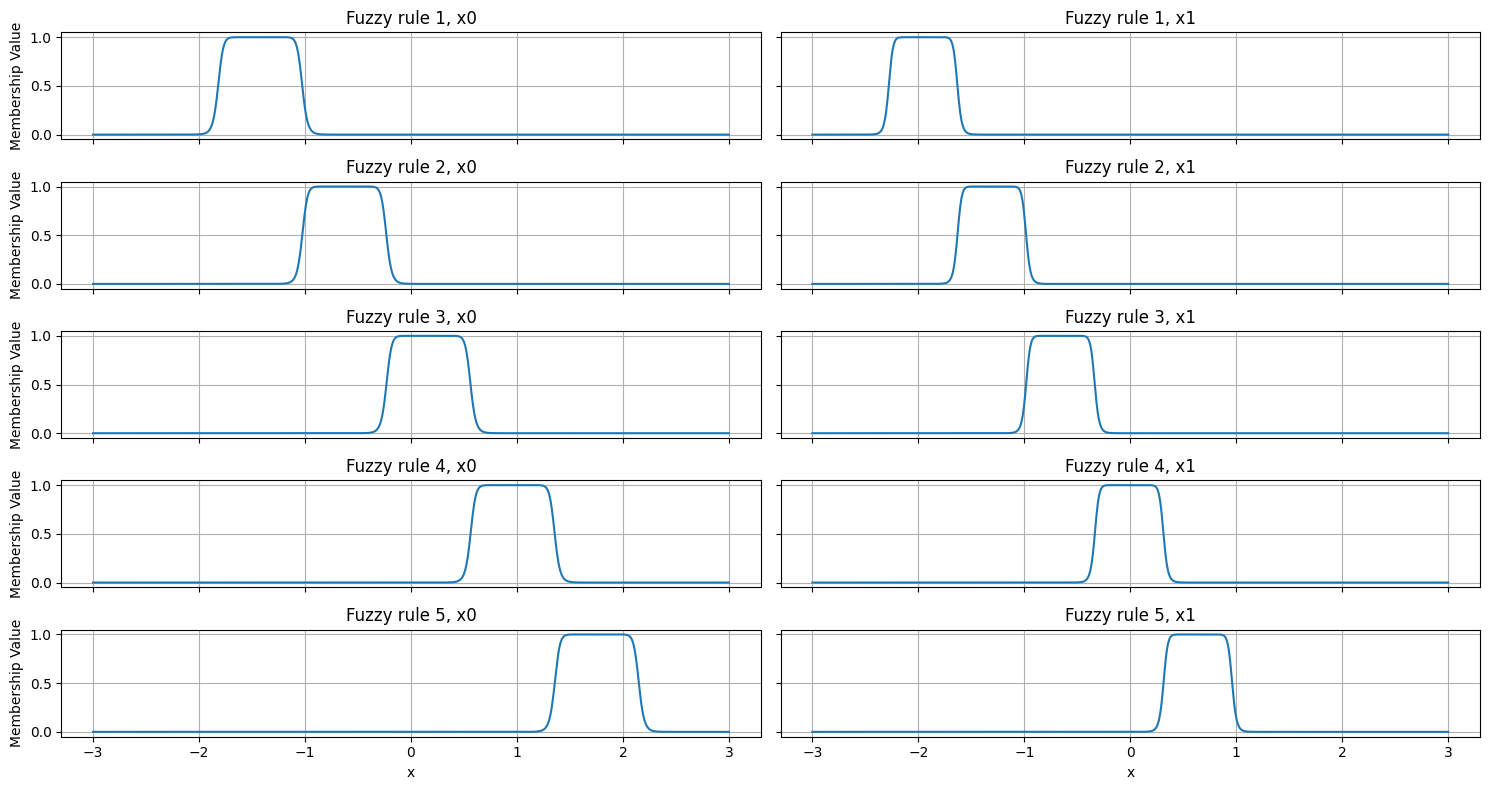

In [31]:
test_anfis = Restricted_ANFIS(x_train, init_rules=5)
test_anfis.plot_premises

In [32]:
test_anfis(x_train)

tensor([[-1.6388, -0.8332, -0.8689,  0.2257,  0.0203, -0.4908, -1.3401, -0.0157,
         -0.1571, -1.1949]], grad_fn=<SumBackward1>)

In [33]:
test_anfis(x_train[0])

tensor([[-1.6388]], grad_fn=<SumBackward1>)

### Multiple Output

In [41]:
x_train = torch.randn(10, 4)
x_train

tensor([[-0.0964, -0.4371, -0.2860,  0.5402],
        [ 0.0739, -0.1876,  1.3712,  0.7593],
        [ 1.1397, -0.7196, -2.4760, -0.6931],
        [-0.8417, -0.8812,  0.2885,  0.7538],
        [ 1.5526, -1.2931,  0.4504, -1.2634],
        [ 1.2773, -0.5673,  0.7859,  1.2129],
        [-1.0316,  0.9749, -0.5814, -0.8149],
        [ 2.1168, -1.2552, -1.1450,  0.0968],
        [-0.0424, -0.3727,  0.5905, -0.5176],
        [-0.8769,  0.3274, -1.4934, -0.9299]])

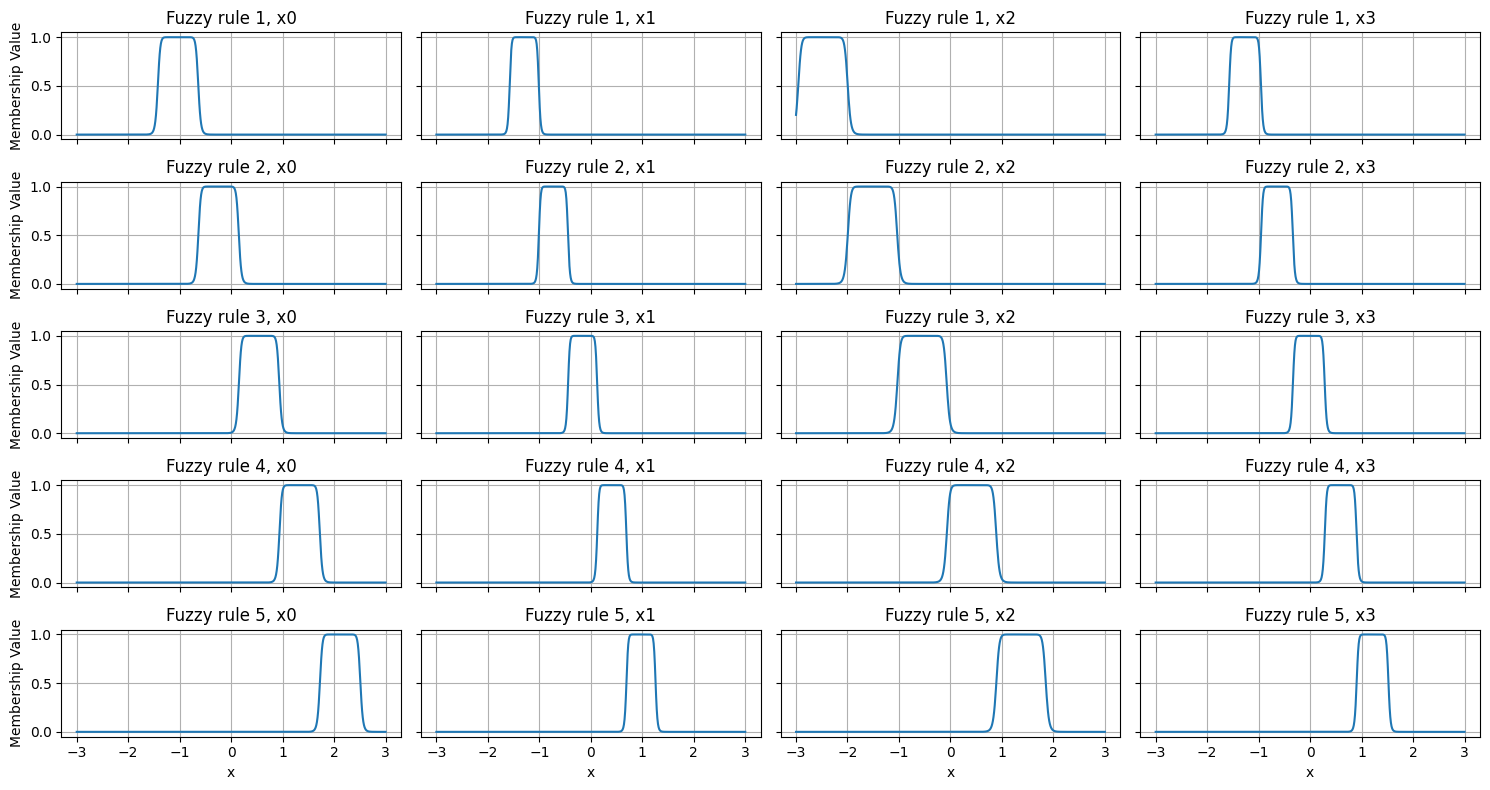

In [42]:
test_mul_anfis = Restricted_ANFIS(x_train, init_rules=5, output_type='multiclass', outputs_amount=3)
test_mul_anfis.plot_premises

In [43]:
test_mul_anfis(x_train)

tensor([[0.1846, 0.0279, 0.0326, 0.0454, 0.4985, 0.0216, 0.4131, 0.0496, 0.1171,
         0.3048],
        [0.2280, 0.4898, 0.9290, 0.2605, 0.0769, 0.2391, 0.2855, 0.0052, 0.4591,
         0.4515],
        [0.5874, 0.4823, 0.0383, 0.6941, 0.4246, 0.7393, 0.3014, 0.9451, 0.4238,
         0.2437]], grad_fn=<SoftmaxBackward0>)

In [44]:
test_mul_anfis.classes_prediction(x_train)

tensor([2, 1, 1, 2, 0, 2, 0, 2, 1, 1])